<a href="https://colab.research.google.com/github/AllaYermilko/DTA-2026/blob/main/Stat/practice_stat_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [12]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [4]:
# Завдання 1:
df.describe().round(2)

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,1250.50,34.65,845.02,20.74,6.54,7.14
std,144.48,10.96,333.46,10.53,1.52,1.83
min,1001.00,18.00,50.00,1.00,2.00,1.00
25%,1125.75,26.00,612.63,13.10,6.00,6.00
50%,1250.50,34.00,834.75,20.85,7.00,7.00
75%,1375.25,41.25,1070.40,27.40,8.00,9.00
max,1500.00,69.00,1952.02,52.20,10.00,10.00


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [5]:
# Завдання 2:
df['channel'].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [6]:
# Завдання 3:


mean_session = df["session_min"].mean()
print(f"Фактичне середнє: {mean_session:.1f} хвилин")

t_stat, p_value = stats.ttest_1samp(df["session_min"], 20)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 20")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20")


Фактичне середнє: 20.7 хвилин
t-статистика: 1.570
p-значення:   0.1171

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 20


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?



**Ваша відповідь:**

Статистично середній час на сайті не відрізняється від заявлених 20 хвилин. Хоча фактичне середнє значення вибірці становить 20.7 хвилин, проведений одновибірковий t-тест показав, що p-значення дорівнює 0.1171 (11.7%), що значно більше за критичний рівень значущості 0.05 (5%). Різниця в 0.7 хвилини не є закономірністю — вона випадкова і викликана звичайною похибкою вибірки.

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [ ]:
# Завдання 4:
mean_spend = df["spend"].mean()
print(f"Фактичне середнє: {mean_spend:.1f} грн.")

t_stat, p_value = stats.ttest_1samp(df["spend"], 850)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 850")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 850")

Фактичне середнє: 845.0 грн.
t-статистика: -0.334
p-значення:   0.7384

❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 850


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест показав, що немає статистично значущої різниці між фактичними витратами (845.0 грн) та заявленими 850 грн. Різниця у 5 гривень є занадто дрібною та випадковою для цієї вибірки.  
Ми не відхиляємо нульову гіпотезу, тому що отримане p-значення дорівнює 0.7384 (73.84%), що значно більше за критичний поріг 0.05 (5%). Якби справжнє середнє значення всього магазину дорівнювало 850 грн, то у 74% випадків ми могли б випадково отримати середнє 845 грн через невизначеність вибірки. Оскільки ймовірність такого «випадку» велика (74%), відхилення в 5 гривень можна списати на звичайну похибку вимірювання і залишити нульову гіпотезу в силі.3.  
*Чи означає це, що середнє точно дорівнює 850? *   
Ні, це не означає, що воно точно дорівнює 850. Ми не довели, що середнє дорівнює рівно 850.00 грн. Ми довели, що у нас немає аргументів стверджувати, що воно не дорівнює 850.

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [7]:
# Завдання 5:
spend_m = df[df["device"] == "Mobile"]["spend"]
spend_d = df[df["device"] == "Desktop"]["spend"]

print(f"Mobile:  {spend_m.mean():.1f}")
print(f"Desktop: {spend_d.mean():.1f}")

t_stat, p_value = stats.ttest_ind(spend_m, spend_d)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Значуща різниця між девайсами")
else:
    print("❌ Значущої різниці НЕ виявлено")

Mobile:  835.2
Desktop: 861.2

p-значення: 0.3993
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**  
Користувачі Desktop в середньому витрачають трохи більше (861,2 грн.), ніж користувачі Mobile (835,2 грн.), різниця становить 26 гривень.  
Р-значення становить 0.3993 (39.93%), що значно більше за критичний поріг 0,05. То ж можна зробити висновок, що значущої різниці у витратах між користувачами мобільних телефонів та комп'ютерів немає.
Ми не маємо підстав стверджувати, що тип пристрою впливає на суму покупок клієнтів.

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [ ]:
# Завдання 6:
time_m = df[df["gender"] == "Ч"]["session_min"]
time_f = df[df["gender"] == "Ж"]["session_min"]

print(f"Чоловіки: {time_m.mean():.1f} хвилин")
print(f"Жінки:    {time_f.mean():.1f} хвилин")

t_stat, p_value = stats.ttest_ind(time_m, time_f)
print(f"\np-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Значуща різниця між статями")
else:
    print("❌ Значущої різниці НЕ виявлено")

Чоловіки: 20.8 хвилин
Жінки:    20.6 хвилин

p-значення: 0.8163
❌ Значущої різниці НЕ виявлено


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Проведений t-тест показав, що статистично значущої різниці у часі перебування на сайті між чоловіками та жінками немає. Фактична різниця між середніми значеннями є мінімальною і складає 12 секунд.  
Високе p-значення (0.8163) вказує на те, що ця розбіжність є випадковою похибкою вибірки. Стать користувача не впливає на тривалість сесії на сайті.  

Для відділу маркетингу: немає сенсу витрачати час на розділення реклами чи дизайну сайту окремо для чоловіків чи жінок. Сайт має бути зручним та інтуїтивним для всіх.  
Щоб підвищити час перебування відвідувачів на сайті можна попрацювати над редизайном сайту.


---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [9]:
# Завдання 7:

print(f"Задоволеність ДО:    {df['sat_before'].mean():.2f}")
print(f"Задоволеність ПІСЛЯ: {df['sat_after'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(df["sat_before"], df["sat_after"])
print(f"\np-значення: {p_value:.6f}")  # p_value:.2e отримаємо в такому вигляді: 1.57e-26

if p_value < 0.05:
    print("✅ Задоволеність значущо змінилася")
else:
    print("❌ Значущої зміни не виявлено")

Задоволеність ДО:    6.54
Задоволеність ПІСЛЯ: 7.14

p-значення: 0.000000
✅ Задоволеність значущо змінилася


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Редизайн спрацював успішно. Середня задоволеність користувачів зросла з 6.54 до 7.14 балів.   
p-значення: 0.000000, це зростання є статистично значущим. Це не випадковий збіг, а реальний позитивний ефект від оновлення сайту.
Парний тест тут доречний, тому що ми порівнюємо задоволеність одних і тих самих людей в різні періоди часу, до зміни дизайну сайту та після цього.  
Звичайний тест ttest_ind призначений для незалежних груп. У випадку використання цього тесту на даному прикладі, були б помилки, бо ми б порівнювали незалежні групи. ttest_ind міг просто не помітити реальних покращень і помилково показати, що редизайн не спрацював.

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [ ]:
# Завдання 8:
for channel in df["channel"].unique():
    avg = df[df["channel"] == channel]["spend"].mean()
    print(f"{channel}: {avg:.1f} грн")

groups = [df[df["channel"] == ch]["spend"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні один канал значущо відрізняється")
else:
    print("❌ Значущої різниці між каналами немає")

Реклама: 1057.9 грн
Органіка: 791.3 грн
Соцмережі: 698.4 грн

F-статистика: 63.54
p-значення:   0.000000
✅ Принаймні один канал значущо відрізняється


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест ANOVA показав, що канали значно відрізняються за витратами. Різниця між середніми чеками в різних каналах є реальною, а не випадковим збігом.  
Найприбутковішим каналом є Реклама. Клієнти, які приходять через нього, залишають у магазині найбільше грошей — в середньому 1057,9 грн. Це значно більше, ніж в Органіці (791,3 грн) та Соцмережах (698,4 грн).  
Тест ANOVA не порівнює групи попарно. Тому ми не можемо точно сказати, що Реклама значущо краща за Органіку, оскільки тест дає лише загальний результат для всіх трьох груп.

**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [ ]:
# Завдання 9:
for country in df["country"].unique():
    avg = df[df["country"] == country]["session_min"].mean()
    print(f"{country}: {avg:.1f} хвилин")

groups = [df[df["country"] == ch]["session_min"] for ch in df["country"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні один канал значущо відрізняється")
else:
    print("❌ Значущої різниці між каналами немає")

Німеччина: 21.3 хвилин
Україна: 20.3 хвилин
Польща: 21.2 хвилин

F-статистика: 0.49
p-значення:   0.611082
❌ Значущої різниці між каналами немає


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Тест ANOVA показав, що країна проживання користувача взагалі не впливає на час, який він проводить на сайті. Хоча середні значення в хвилинах трохи відрізняються (Німеччина — 21.3 хв, Польща — 21.2 хв, Україна — 20.3 хв), отримане p-значення дорівнює 0.611082 (61.1%). Це набагато більше за стандартний поріг 0.05. Це означає, що така невелика різниця в 1 хвилину є абсолютно випадковою і викликана звичайним коливанням даних у вибірці. Статистично значущого зв'язку між країною та часом на сайті немає.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [ ]:
# Завдання 10:
contingency = pd.crosstab(df["channel"], df["purchased"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Пристрій ПОВ'ЯЗАНИЙ із покупкою")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

chi2: 0.957
p-значення: 0.6198
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Проведений тест Хі-квадрат не виявив жодного статистично значущого зв'язку між каналом залучення та фактом покупки. Отримане p-значення становить 0.6198 (61.98%), що значно вище за критичний поріг 0.05. Це означає, що коливання у кількості покупок між Органікою, Рекламою та Соцмережами є абсолютно випадковими, а відсоток людей, які купують в усіх каналах є приблизно однаковою.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [ ]:
# Завдання 11:
contingency = pd.crosstab(df["gender"], df["device"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Стать ПОВ'ЯЗАНА з вибором пристрою")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

chi2: 0.065
p-значення: 0.7993
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**  

За результатами проведеного тесту жодного зв'язку між статтю користувача та вибором пристрою не виявлено. Отримане p-значення становить 0.7993 (79.93%), що набагато більше за поріг 0.05. Це означає, що чоловіки та жінки вибирають пристрої абсолютно однаково, а незначна різниця у кілька людей є випадковою.

---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

In [ ]:
# Завдання 12:
r, p_value = stats.pearsonr(df["session_min"], df["spend"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.6f}")

# r близький до 1 → сильний прямий зв'язок; до 0 → зв'язку немає
if p_value < 0.05:
    print("✅ Зв'язок статистично значущий")
else:
    print("❌ Значущого зв'язку немає")

Коефіцієнт кореляції r: 0.732
p-значення: 0.000000
✅ Зв'язок статистично значущий


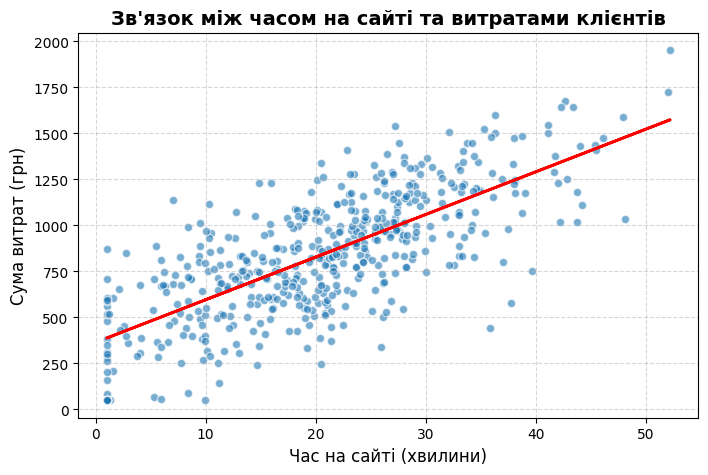

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["session_min"], df["spend"], alpha=0.6, color='#1f77b4', edgecolors='w')

m, b = np.polyfit(df["session_min"], df["spend"], 1)
plt.plot(df["session_min"], m * df["session_min"] + b, color='red', linewidth=2)

plt.title("Зв'язок між часом на сайті та витратами клієнтів", fontsize=14, fontweight='bold')
plt.xlabel("Час на сайті (хвилини)", fontsize=12)
plt.ylabel("Сума витрат (грн)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Коефіцієнт кореляції r ≈ 0.73 (що вказує на сильний прямий зв'язок) і p < 0.001 (значущий). Чим більше часу клієнт на сайті, тим більше витрачає коштів.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [10]:
# Завдання 13:
r, p_value = stats.pearsonr(df["age"], df["spend"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.6f}")

# r близький до 1 → сильний прямий зв'язок; до 0 → зв'язку немає
if p_value < 0.05:
    print("✅ Зв'язок статистично значущий")
else:
    print("❌ Значущого зв'язку немає")

Коефіцієнт кореляції r: -0.042
p-значення: 0.350752
❌ Значущого зв'язку немає


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Коефіцієнт кореляції r ≈ -0.042 (майже дорівнює нулю)  і p < 0.350752 (підтверджує, що результат кореяції випадковий).
Кореляція між віком та витратами показала, що ніякого зв'язку між цими метриками немає.

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [14]:
# Завдання 14:
print(ab['group'].value_counts())

group
A    4000
B    4000
Name: count, dtype: int64


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [15]:
# Завдання 15:
conversion_rates = ab.groupby('group')['converted'].mean()
print(conversion_rates)

cr_a = conversion_rates['A'] * 100
cr_b = conversion_rates['B'] * 100
diff = cr_b - cr_a

print(f"\nКонверсія групи A: {cr_a:.2f}%")
print(f"Конверсія групи B: {cr_b:.2f}%")
print(f"Різниця: {diff:.2f} в.п.")

group
A    0.101
B    0.119
Name: converted, dtype: float64

Конверсія групи A: 10.10%
Конверсія групи B: 11.90%
Різниця: 1.80 в.п.


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Група B показує вищу конверсію (11.90%).  

*Чи означає ця різниця в числах, що версія B точно краща?* Без тесту не можна стверджувати, що вона точно краща.  

*Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?*  
Різниця в 1.80 в.п. може бути випадковим результатом у даних, а не результатом оновлення сайту. 4000 сесій на групу — це обмежені дані. Треба математично перевірити, чи достатньо цієї кількості, щоб різниця вважалася закономірністю.Необхідно провести тест хі-квадрат і визначити p-значення. Якщо воно буде меншим за 0.05, тоді група B дійсно краща. Якщо більшим — це випадковість

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Нульова гіпотеза (H₀): Оновлення сайту ні на що не вплинуло. Різниця в конверсії між групами A і B є чисто випадковою.  
Альтернативна гіпотеза (H₁): Нова версія сайту реально працює. Різниця в конверсії є значущою і викликана саме змінами у версії B.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [18]:
# Завдання 16:
contingency = pd.crosstab(ab["group"], ab["converted"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Нова версія сайту (B) статистично значуще покращує конверсію")
else:
    print("❌ Зміни на сайті не вплинули на конверсію, різниця випадкова")

Таблиця спряженості:
converted     0    1
group               
A          3596  404
B          3524  476

chi2: 6.436
p-значення: 0.011180
✅ Нова версія сайту (B) статистично значуще покращує конверсію


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Ми можемо відхилити  нульову гіпотезу, оскільки отримане p-значення (0.011) є меншим за рівень значущості 0.05.  
Різниця в конверсії між групами є статистично значущою, а не випадковою. Нова версія сайту збільшила конверсію з 10.1% до 11.9% (+1.8 в.п.).  
Рекомендація для продуктової команди: впроваджувати версію B на 100% користувачів. Це оновлення реально стимулює продажі й принесе компанії додатковий прибуток, тому проект можна вважати успішним.

---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Я буду застосовувати тест ANOVA (порівняння 3+ груп, в нашому випадку трьох каналів залучення)

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [19]:
# Завдання 17:
for channel in df["channel"].unique():
    avg = df[df["channel"] == channel]["age"].mean()
    print(f"{channel}: {avg:.1f} років")

groups = [df[df["channel"] == ch]["age"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-значення:   {p_value:.6f}")

if p_value < 0.05:
    print("✅ Принаймні один канал значущо відрізняється")
else:
    print("❌ Значущої різниці між каналами немає")

Реклама: 35.4 років
Органіка: 34.4 років
Соцмережі: 34.2 років

F-статистика: 0.60
p-значення:   0.549838
❌ Значущої різниці між каналами немає


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Отримане p-значення (0.55) значно більше за рівень значущості α = 0.05, а F-статистика близька до нуля (0.60). Це означає, що ми не можемо відхилити нульову гіпотезу. Невеликі коливання в середньому віці клієнтів (від 34.2 до 35.4 років) є суто випадковими й статистично не значущими.  
Для бізнесу це означає, що аудиторія в усіх трьох каналах залучення (Реклама, Органіка, Соцмережі) однакова за віком. Маркетологам немає сенсу адаптувати контент чи пропозиції під різні вікові категорії для цих каналів, оскільки скрізь купують люди приблизно одного віку — близько 34–35 років.

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Я буду використовувати одновибірковий t-тест

Гіпотези:

H₀: середні витрати = 900  
H₁: середні витрати ≠ 900

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [20]:
# Завдання 18:
mean_spend = df["spend"].mean()
print(f"Фактичне середнє: {mean_spend:.1f} грн")

t_stat, p_value = stats.ttest_1samp(df["spend"], 900)
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значення:   {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 900")
else:
    print("\n❌ p ≥ 0.05 → не значущо: немає підстав казати, що середнє ≠ 900")

Фактичне середнє: 845.0 грн
t-статистика: -3.687
p-значення:   0.0003

✅ p < 0.05 → значущо: середнє ВІДРІЗНЯЄТЬСЯ від 900


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Отримане p-значення (0.0003) є значно меншим за 0.05, що свідчить про високу статистичну значущість результату. Тест показав, що реальний середній чек відрізняється від цифри, яку назвав маркетолог. Фактичне середнє становить 845.0 грн, що менше за заявлені 900 грн (t-статистика від'ємна).
Рекомендація для бізнесу: орієнтуватися на реальну цифру у 845 грн для фінансового планування, оскільки маркетолог переоцінив витрати клієнтів.  

**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

В данному випадку буду використовувати тест Хі-квадрат (звʼязок категорій).  
Обидві змінні категоріальні → хі-квадрат.

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [21]:
# Завдання 19:
contingency = pd.crosstab(df["country"], df["device"])
print("Таблиця спряженості:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2: {chi2:.3f}")
print(f"p-значення: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Пристрій ПОВ'ЯЗАНИЙ із країною")
else:
    print("❌ Зв'язку не виявлено")

Таблиця спряженості:
device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

chi2: 1.207
p-значення: 0.5470
❌ Зв'язку не виявлено


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Отримане p-значення (0.5470) значно більше за рівень значущості α = 0.05, а показник chi2 є дуже низьким (1.207). Це означає, що ми не можемо відхилити нульову гіпотезу. Статистично значущого зв'язку між країною клієнта та типом пристрою немає. В усіх трьох країнах (Україна, Польща, Німеччина) пропорції користувачів смартфонів та комп'ютерів є майже однаковими.

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Буду використовувати Кореляцію (зв'язок двох чисел)
Обидві змінні числові (вік та час на сайті) → кореляція Пірсона.

#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [22]:
# Завдання 20:
r, p_value = stats.pearsonr(df["age"], df["session_min"])
print(f"Коефіцієнт кореляції r: {r:.3f}")
print(f"p-значення: {p_value:.6f}")

# r близький до 1 → сильний прямий зв'язок; до 0 → зв'язку немає
if p_value < 0.05:
    print("✅ Зв'язок статистично значущий")
else:
    print("❌ Значущого зв'язку немає")

Коефіцієнт кореляції r: -0.012
p-значення: 0.789823
❌ Значущого зв'язку немає


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Напрямок: маємо знак минус перед коефіцієнтом, тож можемо сказати, що напрямок негативний.  
Сила: Зв'язок повністю відсутній (нульовий). Коефіцієнт кореляції (r = -0.012) знаходиться дуже близько до нуля, що свідчить про повну незалежність метрик одна від одної.
Значущість: Зв'язок статистично не значущий. Оскільки p-значення (0.789) набагато більше за (0.05), будь-які мінімальні коливання в даних є випадковими.

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
